<a href="https://colab.research.google.com/github/Dharani865/Python/blob/main/CropYieldPrediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Data Loading and Initial Inspection

In [ ]:
import pandas as pd
df = pd.read_csv('yield_df.csv')
print("First 5 rows of the dataset:")
display(df.head())
print("\nDataset Information:")
df.info()

First 5 rows of the dataset:


,Unnamed: 0,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
0,0,Albania,Maize,1990,36613,1485.0,121.0,16.37
1,1,Albania,Potatoes,1990,66667,1485.0,121.0,16.37
2,2,Albania,"Rice, paddy",1990,23333,1485.0,121.0,16.37
3,3,Albania,Sorghum,1990,12500,1485.0,121.0,16.37
4,4,Albania,Soybeans,1990,7000,1485.0,121.0,16.37



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28242 entries, 0 to 28241
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Unnamed: 0                     28242 non-null  int64  
 1   Area                           28242 non-null  object 
 2   Item                           28242 non-null  object 
 3   Year                           28242 non-null  int64  
 4   hg/ha_yield                    28242 non-null  int64  
 5   average_rain_fall_mm_per_year  28242 non-null  float64
 6   pesticides_tonnes              28242 non-null  float64
 7   avg_temp                       28242 non-null  float64
dtypes: float64(3), int64(3), object(2)
memory usage: 1.7+ MB


Data preprocessing

In [ ]:
print("Checking for missing values:")
display(df.isnull().sum())

categorical_cols = df.select_dtypes(include=['object', 'category']).columns

if len(categorical_cols) > 0:
    print(f"\nApplying one-hot encoding to categorical columns: {list(categorical_cols)}")
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print("\nDataset after preprocessing (first 5 rows):")
display(df.head())
print("\nUpdated Dataset Information:")
df.info()

Checking for missing values:


,0
Unnamed: 0,0
Area,0
Item,0
Year,0
hg/ha_yield,0
average_rain_fall_mm_per_year,0
pesticides_tonnes,0
avg_temp,0



Applying one-hot encoding to categorical columns: ['Area', 'Item']

Dataset after preprocessing (first 5 rows):


,Unnamed: 0,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp,Area_Algeria,Area_Angola,Area_Argentina,Area_Armenia,...,Area_Zimbabwe,Item_Maize,Item_Plantains and others,Item_Potatoes,"Item_Rice, paddy",Item_Sorghum,Item_Soybeans,Item_Sweet potatoes,Item_Wheat,Item_Yams
0,0,1990,36613,1485.0,121.0,16.37,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False
1,1,1990,66667,1485.0,121.0,16.37,False,False,False,False,...,False,False,False,True,False,False,False,False,False,False
2,2,1990,23333,1485.0,121.0,16.37,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
3,3,1990,12500,1485.0,121.0,16.37,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False
4,4,1990,7000,1485.0,121.0,16.37,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False



Updated Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28242 entries, 0 to 28241
Columns: 115 entries, Unnamed: 0 to Item_Yams
dtypes: bool(109), float64(3), int64(3)
memory usage: 4.2 MB


Model prediction

Training a RandomForestRegressor model...

Model Evaluation:
Mean Squared Error (MSE): 0.66
Root Mean Squared Error (RMSE): 0.81
R-squared (R2) Score: 0.99


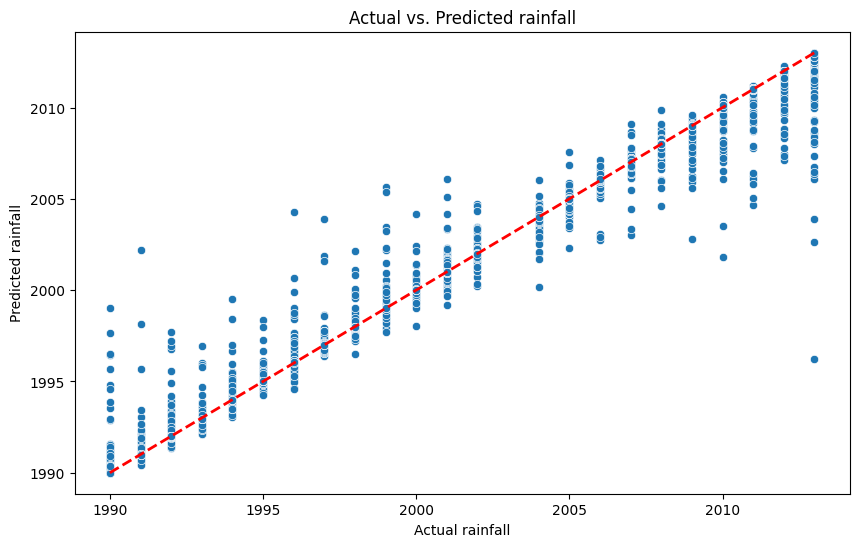

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# Ensure target_variable is defined for the model prediction step
target_variable = 'Year'

if not df.empty and target_variable in df.columns:
    # Define features (X) and target (y)
    X = df.drop(columns=[target_variable])
    y = df[target_variable]

    # Split data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    print("Training a RandomForestRegressor model...")
    # Initialize and train the model
    model = RandomForestRegressor(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)

    # Make predictions on the test set
    y_pred = model.predict(X_test)

    # Evaluate the model
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    print(f"\nModel Evaluation:")
    print(f"Mean Squared Error (MSE): {mse:.2f}")
    print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
    print(f"R-squared (R2) Score: {r2:.2f}")

    # Visualize predictions vs actual values
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x=y_test, y=y_pred)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # Ideal line
    plt.xlabel("Actual rainfall")
    plt.ylabel("Predicted rainfall")
    plt.title("Actual vs. Predicted rainfall")
    plt.show()
else:
    print("Model prediction skipped due to empty DataFrame or missing target variable.")